# Dataset Exploration

This notebook demonstrates loading the Fama–French 5‑factor dataset, inspecting
its structure, and visualizing the factor returns over time.  The helper
function `load_fama_french` from the `src.data.loader` module is used so the
same preprocessing logic as the rest of the project is applied.

In [12]:
import sys, os
root = os.path.abspath(os.path.join(os.getcwd(), ".."))
print("notebook cwd", os.getcwd())
print("workspace root", root)
# ensure workspace root and src folder are in path
sys.path.insert(0, root)
sys.path.insert(0, os.path.join(root, "src"))
print("sys.path[0:3]", sys.path[0:3])

import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_fama_french
from src.utils.plotting import plot_time_series  # optional helper

notebook cwd c:\Users\lovey\OneDrive\Desktop\local-risk-dynamics\notebooks
workspace root c:\Users\lovey\OneDrive\Desktop\local-risk-dynamics
sys.path[0:3] ['c:\\Users\\lovey\\OneDrive\\Desktop\\local-risk-dynamics\\src', 'c:\\Users\\lovey\\OneDrive\\Desktop\\local-risk-dynamics', 'c:\\Users\\lovey\\OneDrive\\Desktop\\local-risk-dynamics\\src']


In [7]:
# load dataset
csv_path = os.path.abspath(os.path.join(root, "data/raw/F-F_Research_Data_5_Factors_2x3.csv"))
X, y, dates = load_fama_french(csv_path)

df = pd.DataFrame(X, columns=["Mkt-RF","SMB","HML","RMW","CMA"])
df["Date"] = pd.to_datetime(dates, format="%Y%m")
df["ExcessRet"] = y

df.head()

,Mkt-RF,SMB,HML,RMW,CMA,Date,ExcessRet
0,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,1963-07-01,0.0508
1,0.0508,-0.0080,0.0170,0.0040,-0.0038,1963-08-01,-0.0157
2,-0.0157,-0.0043,0.0000,-0.0078,0.0015,1963-09-01,0.0254
3,0.0254,-0.0134,-0.0004,0.0279,-0.0225,1963-10-01,-0.0086
4,-0.0086,-0.0085,0.0173,-0.0043,0.0227,1963-11-01,0.0183


In [8]:
# summary statistics and date range
print(df.describe())
print("Date range", df.Date.min(), "to", df.Date.max())

           Mkt-RF         SMB         HML         RMW         CMA  \
count  816.000000  816.000000  816.000000  816.000000  816.000000   
mean     0.005947    0.002523    0.002917    0.002351    0.002227   
min     -0.231900   -0.155400   -0.138300   -0.189500   -0.070800   
25%     -0.019125   -0.014825   -0.013525   -0.008500   -0.010500   
50%      0.009750    0.000800    0.002300    0.002150    0.000800   
75%      0.033375    0.020725    0.017000    0.012900    0.014725   
max      0.161000    0.184600    0.128600    0.130500    0.090100   
std      0.043668    0.030247    0.028918    0.021773    0.020649   

                                Date   ExcessRet  
count                            816  816.000000  
mean   1992-04-06 01:40:35.294117632    0.005951  
min              1963-07-01 00:00:00   -0.231900  
25%              1974-10-24 06:00:00   -0.019125  
50%              1991-10-16 12:00:00    0.009750  
75%              2008-10-08 18:00:00    0.033375  
max              2025

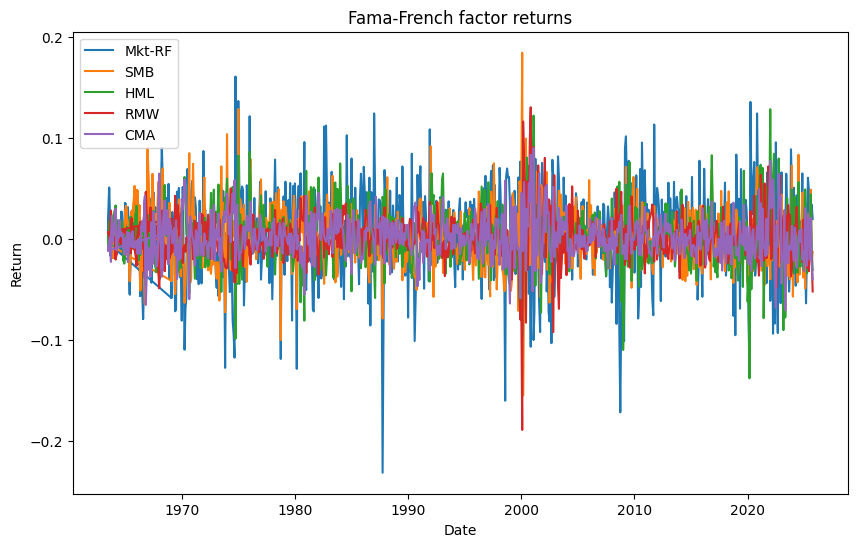

In [9]:
# plot factor returns over time
fig, ax = plt.subplots(figsize=(10,6))
for col in ["Mkt-RF","SMB","HML","RMW","CMA"]:
    ax.plot(df.Date, df[col], label=col)
ax.set_title("Fama-French factor returns")
ax.set_xlabel("Date")
ax.set_ylabel("Return")
ax.legend()
plt.show()

## Next steps

* Use this data as input to the various regression models.
* Perform feature construction or normalization if desired.
* Run time‑series splits before training.